In [1]:
import numpy as np
import pandas as pd
import  igra
from sharppy.sharptab import profile, params, winds, interp, utils
import metpy.calc as mpcalc
from metpy.units import units
from metpy.plots import add_metpy_logo, Hodograph, SkewT
import matplotlib.pyplot as plt
import glob
from copy import deepcopy

In [2]:
# Paths
path_profiles = "/g/data/up6/ai2733/Gusts_downdrafts/data/Profiles_WRF/"
path_igra      ='/g/data/up6/ai2733/Gusts_downdrafts/data/Radiosondes/' 
path_figs     = "/g/data/up6/ai2733/Gusts_downdrafts/figures/Figures/"


In [3]:
# General info
date_cases    = {"CASE1":     ("2015-12-15", "2015-12-16"), 
                 "CASE2_new": ("2009-01-19","2009-01-20"), 
                 "CASE3_new": ("2017-02-16","2017-02-17")}

id_sounding_cases = {"CASE1":     "ASM00095527",
                    "CASE2_new": "ASM00094910"}

dates_radiosonde = {"CASE1":["2015-12-16 00:00:00","2015-12-16 06:00:00"],
                             "CASE2_new":["2009-01-20 00:00:00","2009-01-20 06:00:00"]}


In [6]:
def get_pcl(pres, hght, tmpc, dwpc, u, v, flag):
    """
    Function to create parcel profile
    """
    
    prof = profile.create_profile(profile='default', pres=pres, hght=hght, tmpc=tmpc, \
                                    dwpc=dwpc, u=u*1.94384, v=v*1.94384, missing=-9999, strictQC=False)
    
    return params.parcelx( prof, flag=flag )



def calc_params(pres, hght, tmpc, dwpc, u, v): # U and V in knots
    """
    Function to calculate parameters: to include in skewt-logP diagram
    """
    
    prof = profile.create_profile(profile='default', pres=pres, hght=hght, tmpc=tmpc, \
                                    dwpc=dwpc, u=u*1.94384, v=v*1.94384, missing=-9999, strictQC=False)
    
    sfcpcl = params.parcelx( prof, flag=1 ) # Surface Parcel
    mupcl = params.parcelx( prof, flag=3 ) # Most-Unstable Parcel
    mlpcl = params.parcelx( prof, flag=4 ) # 100 mb Mean Layer Parcel
    
    sfc = prof.pres[prof.sfc]
    p6km = interp.pres(prof, interp.to_msl(prof, 6000.))    
    mean_6km = winds.mean_wind(prof, pbot=sfc, ptop=p6km)
   # print (sfc)
    parcel_disp = sfcpcl
    parcel_text = ""#"Surface-based"
    #print (parcel_disp.bplus, parcel_disp.bminus)
    cin = parcel_disp.bminus.round(1) if parcel_disp.bminus < 0. else parcel_disp.bminus
    text_disp = \
        parcel_text+" CAPE: " + str(parcel_disp.bplus.round(1)) + " J/kg\n" +\
        parcel_text+f" CIN: {cin} J/kg\n" +\
        parcel_text+" LCL: " + str(parcel_disp.lclhght.round(1)) + " m\n" +\
        parcel_text+" LFC: " + str(parcel_disp.lfchght.round(1)) + " m\n" +\
        "DCAPE: " + str(params.dcape(prof)[0].round(1)) + " J/kg\n" +\
        "0-6km Wind: " + str((utils.comp2vec(mean_6km[0], mean_6km[1])[1]/1.94384).round(1)) + " m/s\n" +\
        "Surface T: "+str(tmpc[0].round(1))+" degC\n"+\
        "Surface Td: "+str(dwpc[0].round(1))+" degC"
    
    return text_disp

def get_pcl_nowinds(pres, hght, tmpc, dwpc, flag): # Without winds!!! - It shouldn't matter to calculate the parcel trajectory!

    """
    Function to create parcel profile: ignore winds
    """
    
    prof = profile.create_profile(profile='default', pres=pres, hght=hght, tmpc=tmpc, \
                                    dwpc=dwpc, missing=-9999, strictQC=False, 
                                  wdir = np.zeros(len(pres)), 
                                  wspd = np.zeros(len(pres)))
    
    return params.parcelx( prof, flag=flag )

def calc_params_nowinds(pres, hght, tmpc, dwpc,
                        pres_winds, hght_winds, u, v): # U and V in knots

    """
    Function to calculate parameters: to include in skewt-logP diagram - ignore winds
    """
    
    prof = profile.create_profile(profile='default', pres=pres, hght=hght, tmpc=tmpc, 
                                    dwpc=dwpc, u=np.zeros(len(pres)), v=np.zeros(len(pres)), missing=-9999, strictQC=False)

    sfcpcl = params.parcelx( prof, flag=1 ) # Surface Parcel
    mupcl = params.parcelx( prof, flag=3 ) # Most-Unstable Parcel
    mlpcl = params.parcelx( prof, flag=4 ) # 100 mb Mean Layer Parcel
    sfc = prof.pres[prof.sfc]
    
    # I just create this profile to look at wind data: NOTHING ELSE
    prof_winds = profile.create_profile(profile='default', pres=pres_winds, hght=hght_winds, 
                                        tmpc=np.zeros(len(pres_winds)), dwpc=np.zeros(len(pres_winds)), 
                                        u=u*1.94384, v=v*1.94384, missing=-9999, strictQC=False)
    p_sfc_winds = prof_winds.pres[prof_winds.sfc]
    p_6km_winds = interp.pres(prof_winds, interp.to_msl(prof_winds, 6000.))    
    mean_6km    = winds.mean_wind(prof_winds, pbot=p_sfc_winds, ptop=p_6km_winds)
    
   # print (sfc)
    parcel_disp = sfcpcl
    parcel_text = ""##"Surface-based" ""
    #print (parcel_disp.bplus, parcel_disp.bminus)
    cin = parcel_disp.bminus.round(1) if parcel_disp.bminus < 0. else parcel_disp.bminus
    text_disp = \
        parcel_text+" CAPE: " + str(parcel_disp.bplus.round(1)) + " J/kg\n" +\
        parcel_text+f" CIN: {cin} J/kg\n" +\
        parcel_text+" LCL: " + str(parcel_disp.lclhght.round(1)) + " m\n" +\
        parcel_text+" LFC: " + str(parcel_disp.lfchght.round(1)) + " m\n" +\
        "DCAPE: " + str(params.dcape(prof)[0].round(1)) + " J/kg\n" +\
        "0-6km Wind: " + str((utils.comp2vec(mean_6km[0], mean_6km[1])[1]/1.94384).round(1)) + " m/s\n" +\
        "Surface T: "+str(tmpc[0].round(1))+" degC\n"+\
        "Surface Td: "+str(dwpc[0].round(1))+" degC"
    
    return text_disp
    


In [7]:
def plot_skewT_obs_all(fig, tc, tc_2, tv, td,
                       hgt_td, hgt_winds,
                       p_tc, p_tv, p_td, p_winds,
                       plog, u, ulog, v, vlog, title=""):

    """
    Function to plot observed skewT-logP
    """
    
    fs = 30
    plt.rcParams.update({
    "font.size": fs,
    "axes.titlesize": fs+5,
    "axes.labelsize": fs,
    "xtick.labelsize": fs,
    "ytick.labelsize": fs,
    "legend.fontsize": fs,
    "figure.titlesize": fs,
    "font.family": "Times New Roman",
    })

    
    # Grid for plots
    skew = SkewT(fig, rotation=45)

    # Plot the data using normal plotting functions, in this case using
    # log scaling in Y, as dictated by the typical meteorological plot

    skew.plot(p_tc, tc, 'r', lw=2.5)
    skew.plot(p_tv, tv, 'r', ls=":", lw=2.5)    
    skew.plot(p_td, td, 'g', lw=2.5)
    skew.plot_barbs(plog,ulog,vlog,plot_units=units.meter_per_second,xloc=1.075)
    #skew.ax.set_ylim(1050, 100)

    # Add the relevant special lines
    skew.plot_dry_adiabats()
    skew.plot_moist_adiabats()
    skew.plot_mixing_lines()
    
    #Labels
    plt.xlabel("Temperature (°C)",fontsize=fs)
    plt.ylabel("Pressure (hPa)",fontsize=fs)
    plt.title(title,fontsize = fs)
    skew.ax.text(0.45, 0.96, calc_params_nowinds(pres = np.array(p_td), hght = np.array(hgt_td), tmpc = np.array(tc_2), dwpc = np.array(td),
                            pres_winds = np.array(p_winds), hght_winds = np.array(hgt_winds), u = np.array(u), v = np.array(v)), 
                            transform=skew.ax.transAxes, va="top",ha="left",bbox={"ec":"k","fc":(1, 1, 1, 0.5)},fontsize=fs -5)
    plt.xticks(fontsize = fs) 
    plt.yticks(fontsize = fs)
    
    # Calculate full parcel profile using Sharppy and add to plot as black line. Note this uses a virtual temperature correction
    pcl = get_pcl_nowinds(np.array(p_td), np.array(hgt_td), np.array(tc_2), np.array(td), flag=1)
    skew.plot(pcl.ptrace, pcl.ttrace, 'k-.', lw=2)    


    # Good bounds for aspect ratio
    skew.ax.set_xlim(-30, 40)

    return calc_params_nowinds(pres = np.array(p_td), hght = np.array(hgt_td), tmpc = np.array(tc_2), dwpc = np.array(td),
                            pres_winds = np.array(p_winds), hght_winds = np.array(hgt_winds), u = np.array(u), v = np.array(v))

def plot_skewT_obs(fig, tc, hgt, p, plog, td, u, ulog, v, vlog, title=""):
    """
    Function to plot simulated skewT-logP
    """
    
    fs = 30
    plt.rcParams.update({
    "font.size": fs,
    "axes.titlesize": fs+5,
    "axes.labelsize": fs,
    "xtick.labelsize": fs,
    "ytick.labelsize": fs,
    "legend.fontsize": fs,
    "figure.titlesize": fs,
    "font.family": "Times New Roman",
    })
    
    #Virtual temp
    tv = mpcalc.virtual_temperature_from_dewpoint(p, tc, td)
    
    # Grid for plots
    skew = SkewT(fig, rotation=45)

    # Plot the data using normal plotting functions, in this case using
    # log scaling in Y, as dictated by the typical meteorological plot

    skew.plot(p, tc, 'r', lw=2.5)
    skew.plot(p, tv, 'r', ls=":", lw=2.5)    
    skew.plot(p, td, 'g',lw=2.5)
    skew.plot_barbs(plog,ulog,vlog,plot_units=units.meter_per_second,xloc=1.075)
    #skew.ax.set_ylim(1050, 100)

    # Add the relevant special lines
    skew.plot_dry_adiabats()
    skew.plot_moist_adiabats()
    skew.plot_mixing_lines()
    
    #Labels
    plt.xlabel("Temperature (°C)",fontsize=fs)
    plt.ylabel("Pressure (hPa)",fontsize=fs)
    plt.title(title,fontsize = fs)
    skew.ax.text(0.45, 0.96, calc_params(np.array(p), np.array(hgt), np.array(tc), np.array(td), np.array(u), np.array(v)),
        transform=skew.ax.transAxes, va="top",ha="left",bbox={"ec":"k","fc":(1, 1, 1, 0.5)},fontsize=fs-5)
    plt.xticks(fontsize = fs) 
    plt.yticks(fontsize = fs)
    
    # Calculate full parcel profile using Sharppy and add to plot as black line. Note this uses a virtual temperature correction
    pcl = get_pcl(np.array(p), np.array(hgt), np.array(tc), np.array(td), np.array(u), np.array(v), flag=1)
    skew.plot(pcl.ptrace, pcl.ttrace, 'k-.', lw=2)    

    # Shade areas of CAPE and CIN
    #skew.shade_cape(p,tc, prof)

    # Good bounds for aspect ratio
    skew.ax.set_xlim(-30, 40)

    return calc_params(np.array(p), np.array(hgt), np.array(tc), np.array(td), np.array(u), np.array(v))



## Figure 3: observed sounding

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/numpy/lib/function_base.py:1599: UserWarning: Warning: converting a masked element to nan.
  return interp_func(x, xp, fp, left, right)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/sharppy/sharptab/params.py:2275: RuntimeWarning: divide by zero encountered in scalar divide
  pcl.brn = pcl.bplus / pcl.brnshear


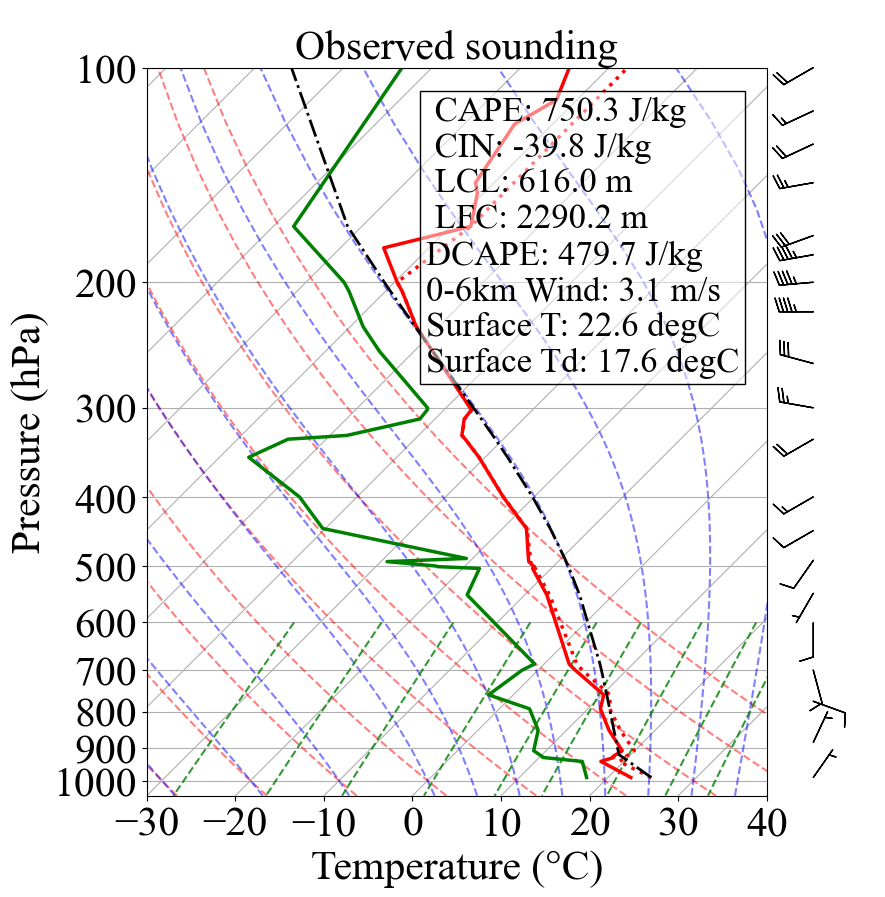

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/numpy/lib/function_base.py:1599: UserWarning: Warning: converting a masked element to nan.
  return interp_func(x, xp, fp, left, right)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/sharppy/sharptab/params.py:2275: RuntimeWarning: divide by zero encountered in scalar divide
  pcl.brn = pcl.bplus / pcl.brnshear


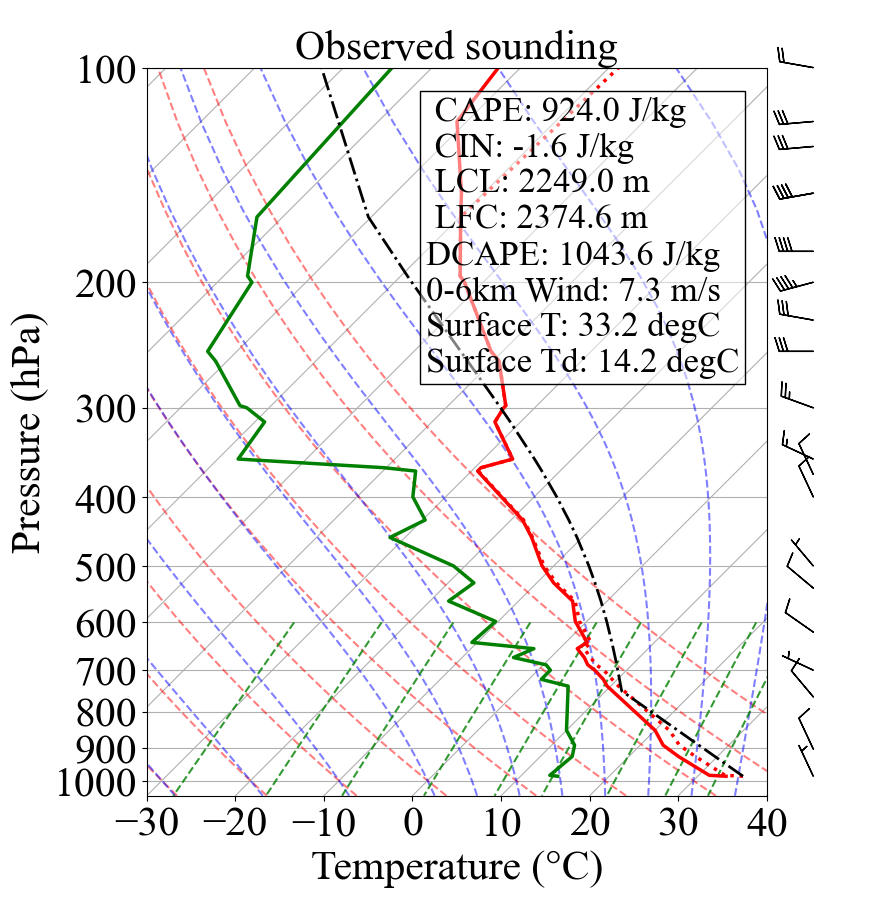

In [9]:
"""
Plot observed soundings
"""
for case in ["CASE1", "CASE2_new"]:
    date_idx = 0
    
    ###############
    # Organise data
    ###############
    
    # Open file - previously downloaded: has all dates! 
    file_case =  glob.glob(f"{path_igra}/*{id_sounding_cases[case]}*.zip")[0]
    data, station = igra.read.ascii_to_dataframe(file_case)
    station.loc[date_cases[case][1]]
    
    #Extract obs data into arrays and assign units
    date_obs = dates_radiosonde[case][date_idx]
    obs_all = deepcopy(data.loc[date_obs]) # This preserves all the data
    
    # Pressure
    obs_all["pres"] = obs_all["pres"]/100. #Pascals to hectopascals
    
    # Height
    obs_all["hgt"] = mpcalc.pressure_to_height_std(obs_all["pres"].values * units.hectopascals) * 1000. #km to meter.magnitude #* units.meters 
    
    # Dew Point Temperature=Ambient Temperature−Dew Point Depression
    obs_all["dpt"] = obs_all["temp"] - obs_all["dpd"]
    
    # Relative humidity 
    obs_all["rh [%]"] = mpcalc.relative_humidity_from_dewpoint(temperature =  obs_all["temp"].values * units.degree_Celsius,
                                                               dewpoint = obs_all["dpt"].values * units.degree_Celsius).to('percent').magnitude
    
    # Wind components
    u_obs_arr, v_obs_arr = mpcalc.wind_components(obs_all["winds"].values * units.meter_per_second,  obs_all["windd"].values * units.degree)
    obs_all["u"] = u_obs_arr.magnitude
    obs_all["v"] = v_obs_arr.magnitude
    
    # Virtual temperature
    obs_all["tv"] = mpcalc.virtual_temperature_from_dewpoint(pressure = obs_all["pres"].values * units.hectopascals,
                                                             temperature = obs_all["temp"].values * units.degree_Celsius,
                                                             dewpoint =  obs_all["dpt"].values * units.degree_Celsius).magnitude
    
    # Temperature
    pres_, temp_  = obs_all[["pres", "temp"]].dropna().values.T
    pres_temp_arr = pres_ * units.hectopascals
    temp_arr      = temp_ * units.degree_Celsius
    
    # Dew Point temperature
    pres_, dptemp_, temp_, hgt_  = obs_all[["pres", "dpt", "temp", "hgt"]].dropna().values.T
    pres_dpt_arr    = pres_ * units.hectopascals    # Same for TV 
    dpt_arr         = dptemp_ * units.degree_Celsius
    hgt_td_arr         = hgt_ * units.meters
    temp_td_arr       = temp_ * units.degree_Celsius
    
    #Virtual temp
    pres_, tv_  = obs_all[["pres", "tv"]].dropna().values.T
    pres_tv_arr    = pres_ * units.hectopascals   
    tv_arr         = tv_ * units.degree_Celsius
    
    # Wind components
    aux_winds =  obs_all[["pres", "hgt", "u", "v"]].dropna()
    pres_, hgt_, u_, v_, = aux_winds.values.T
    p_winds   = pres_ * units.hectopascals
    hgt_winds = hgt_  * units.meters
    u_arr = u_ * units.meter_per_second
    v_arr = v_ * units.meter_per_second
    
    #Get log spacing for p, u and v
    xp = np.flip(pres_)
    yp = np.flip(np.arange(len(pres_)))
    xi = np.logspace(3,2,20)
    pind = np.interp(xi,xp,yp).round().astype(int) 
    #print (pind)
    
    p_obs_logarr = aux_winds["pres"].iloc[pind].values * units.hectopascal
    u_obs_logarr = aux_winds["u"].iloc[pind].values * units.meter_per_second
    v_obs_logarr = aux_winds["v"].iloc[pind].values * units.meter_per_second
    
    ###############
    # Save figure
    ###############
    fig = plt.figure(figsize=(8, 12))
    aux = plot_skewT_obs_all(fig, 
                       tc = temp_arr, tc_2 = temp_td_arr, # tc_2 is just for humidity levels
                       tv = tv_arr, td = dpt_arr, 
                       hgt_td = hgt_td_arr, hgt_winds = hgt_winds,
                       p_tc = pres_temp_arr, p_tv = pres_tv_arr, p_td = pres_dpt_arr, p_winds = p_winds,
                       plog = p_obs_logarr, u = u_arr, ulog = u_obs_logarr, v = v_arr, vlog = v_obs_logarr, 
                       title="Observed sounding")
    
    plt.savefig(f"{path_figs}/Figure1_{case}_obs.pdf", dpi = 600, bbox_inches = "tight")
    plt.show()


## Figure 3: WRF 200 m sounding

In [10]:
def plot_wrf(dom, title_, name_fig):
    # Calculate relative humidity WRF
    temp = wrf_prof[dom]["tc [C]"].values * units.degree_Celsius
    dpt  = wrf_prof[dom]["td [C]"].values * units.degree_Celsius
    rh = mpcalc.relative_humidity_from_dewpoint(temperature = temp, dewpoint = dpt).to('percent')
    wrf_prof[dom]["rh [%]"] = rh.magnitude
    
    # Variables to plot skew-t
    tc_wrf_arr  = wrf_prof[dom]['tc [C]'].values * units.degree_Celsius
    hgt_wrf_arr = wrf_prof[dom]['hgt [m]'].values * units.meters
    p_wrf_arr   = wrf_prof[dom]['p [hPa]'].values * units.hectopascals
    p_wrf_logarr = wrf_prof_log[dom]['p [hPa]'].values * units.hectopascals
    td_wrf_arr  = wrf_prof[dom]['td [C]'].values * units.degree_Celsius
    u_wrf_arr   = wrf_prof[dom]['u [m/s]'].values * units.meter_per_second
    u_wrf_logarr = wrf_prof_log[dom]['u [m/s]'].values * units.meter_per_second
    v_wrf_arr   = wrf_prof[dom]['v [m/s]'].values * units.meter_per_second
    v_wrf_logarr = wrf_prof_log[dom]['v [m/s]'].values * units.meter_per_second

    fig = plt.figure(figsize=(8, 12))
    a = plot_skewT_obs(fig, tc_wrf_arr, hgt_wrf_arr, p_wrf_arr, p_wrf_logarr, td_wrf_arr, u_wrf_arr, u_wrf_logarr, 
                   v_wrf_arr, v_wrf_logarr, 
                   title=title_)

    plt.savefig(f"{path_figs}/{name_fig}.pdf", dpi = 600, bbox_inches = "tight")
    plt.show()


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/numpy/lib/function_base.py:1599: UserWarning: Warning: converting a masked element to nan.
  return interp_func(x, xp, fp, left, right)


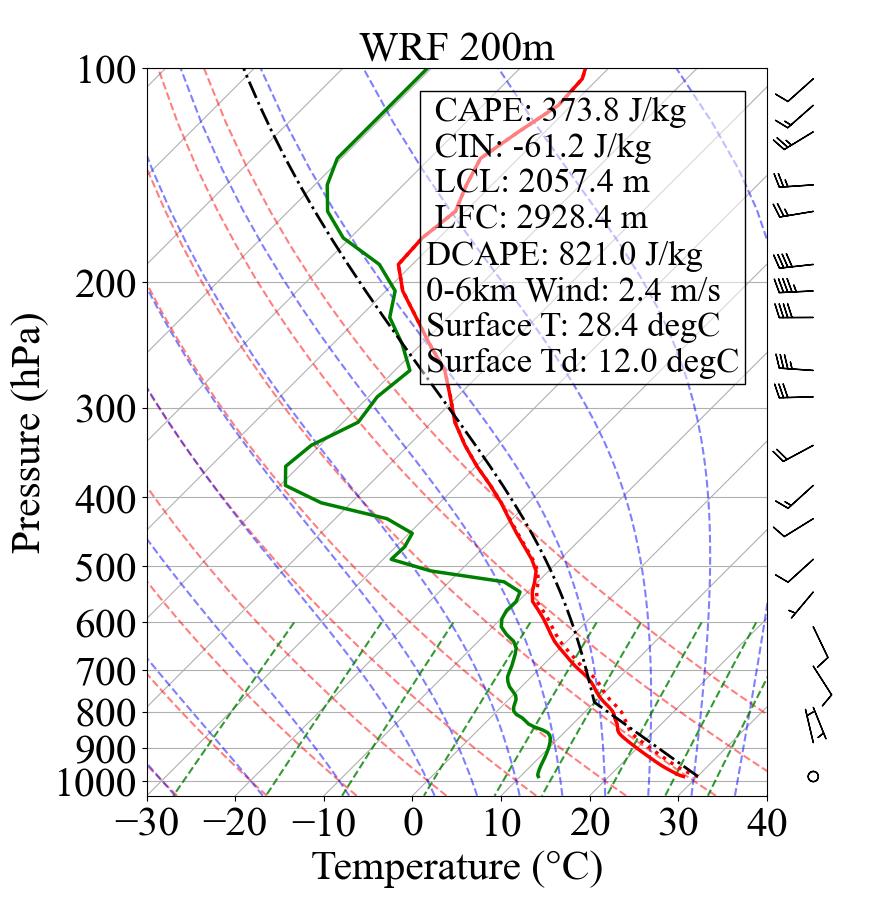

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/numpy/lib/function_base.py:1599: UserWarning: Warning: converting a masked element to nan.
  return interp_func(x, xp, fp, left, right)


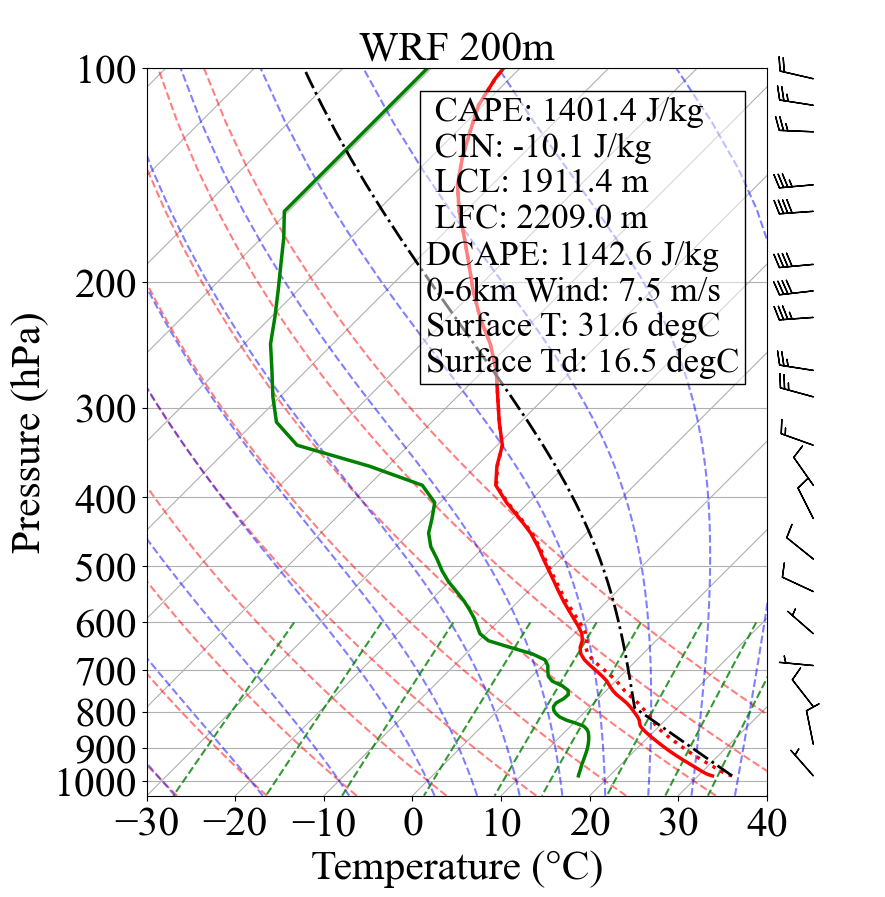

In [11]:
for case in ["CASE1", "CASE2_new"]:
    coarsen = False    
    path_all = f"{path_profiles}/ProfileAWS_{case}_{dates_radiosonde[case][0].replace(' ', 'T')[:-3]}"
    
    wrf_prof, wrf_prof_log = {}, {}
    for dom in ["d03"]:
        if coarsen:
            wrf_prof[dom]     =  pd.read_csv(f"{path_all}_logspaceFalse_{dom}_coarsen5km.csv", index_col = 0, dtype = float)
            wrf_prof_log[dom] = pd.read_csv(f"{path_all}_logspaceTrue_{dom}_coarsen5km.csv", index_col = 0, dtype = float)
        else:
            wrf_prof[dom]     =  pd.read_csv(f"{path_all}_logspaceFalse_{dom}.csv", index_col = 0, dtype = float)
            wrf_prof_log[dom] = pd.read_csv(f"{path_all}_logspaceTrue_{dom}.csv", index_col = 0, dtype = float)            

    plot_wrf("d03", f"WRF 200m", name_fig = f"Figure1_{case}_wrf")

## Figure S1: Sounding from WRF outputs (different resolutions)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/numpy/lib/function_base.py:1599: UserWarning: Warning: converting a masked element to nan.
  return interp_func(x, xp, fp, left, right)


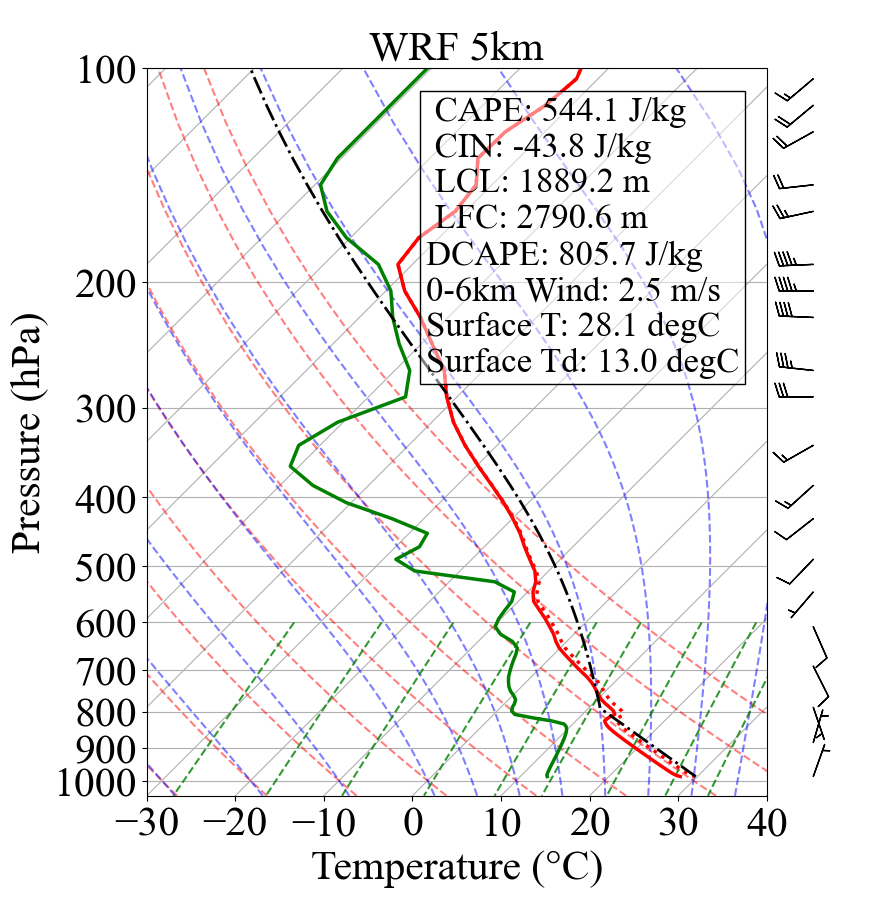

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/numpy/lib/function_base.py:1599: UserWarning: Warning: converting a masked element to nan.
  return interp_func(x, xp, fp, left, right)


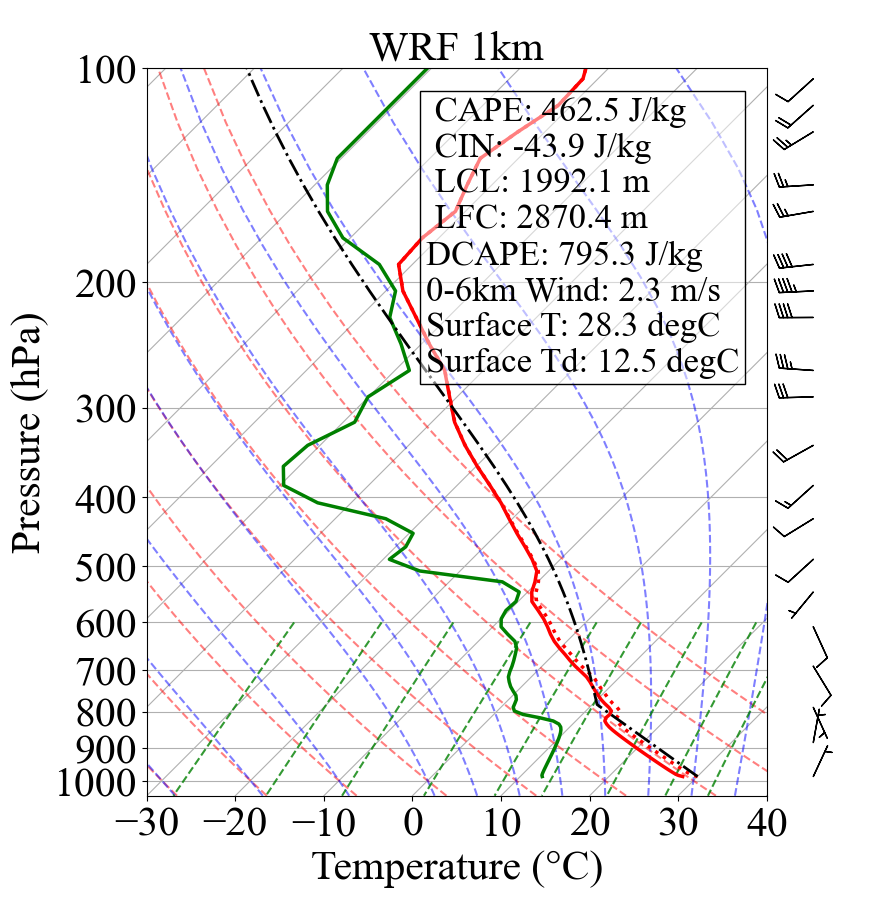

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/numpy/lib/function_base.py:1599: UserWarning: Warning: converting a masked element to nan.
  return interp_func(x, xp, fp, left, right)


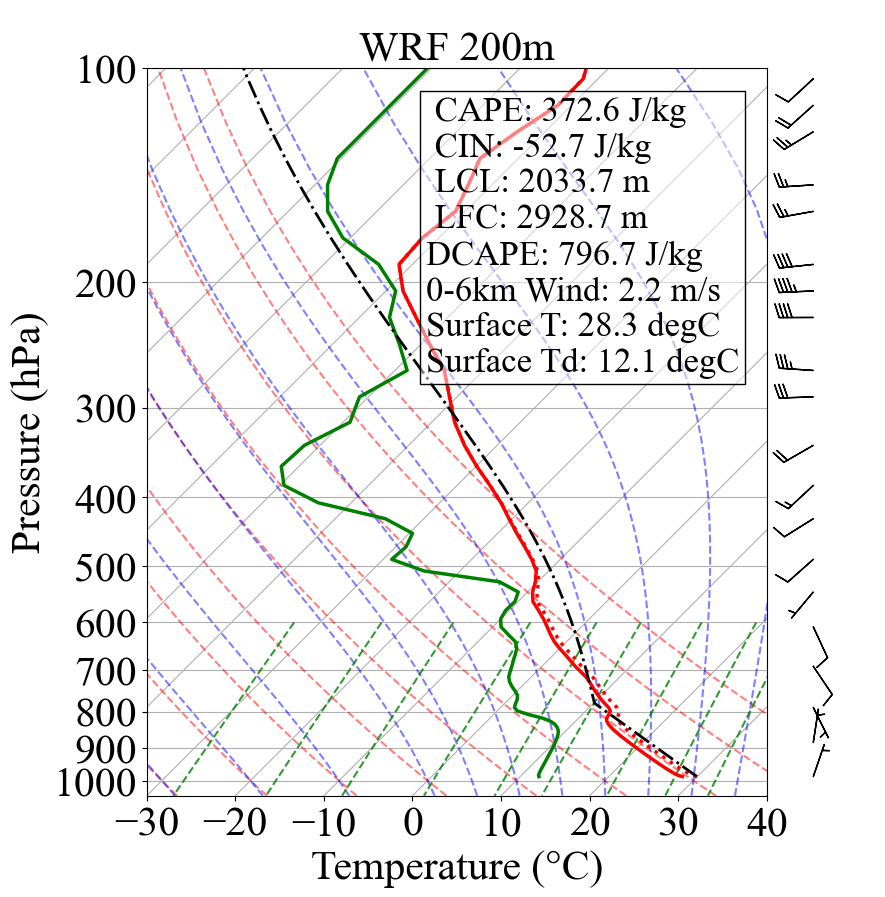

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/numpy/lib/function_base.py:1599: UserWarning: Warning: converting a masked element to nan.
  return interp_func(x, xp, fp, left, right)


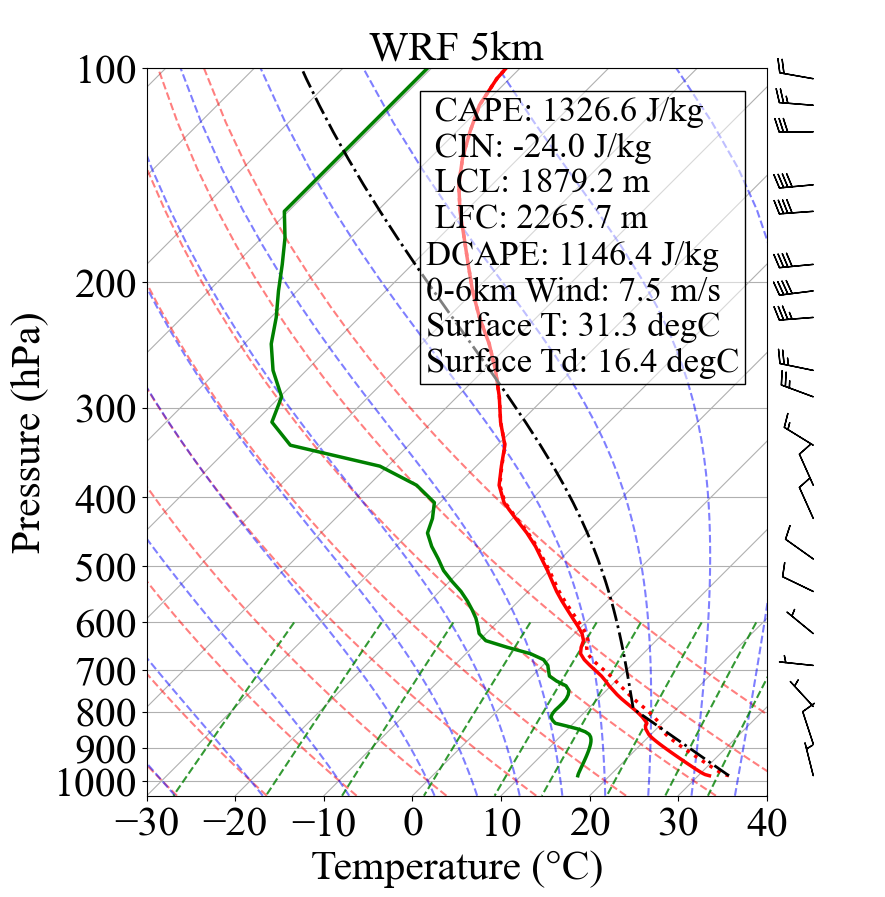

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/numpy/lib/function_base.py:1599: UserWarning: Warning: converting a masked element to nan.
  return interp_func(x, xp, fp, left, right)


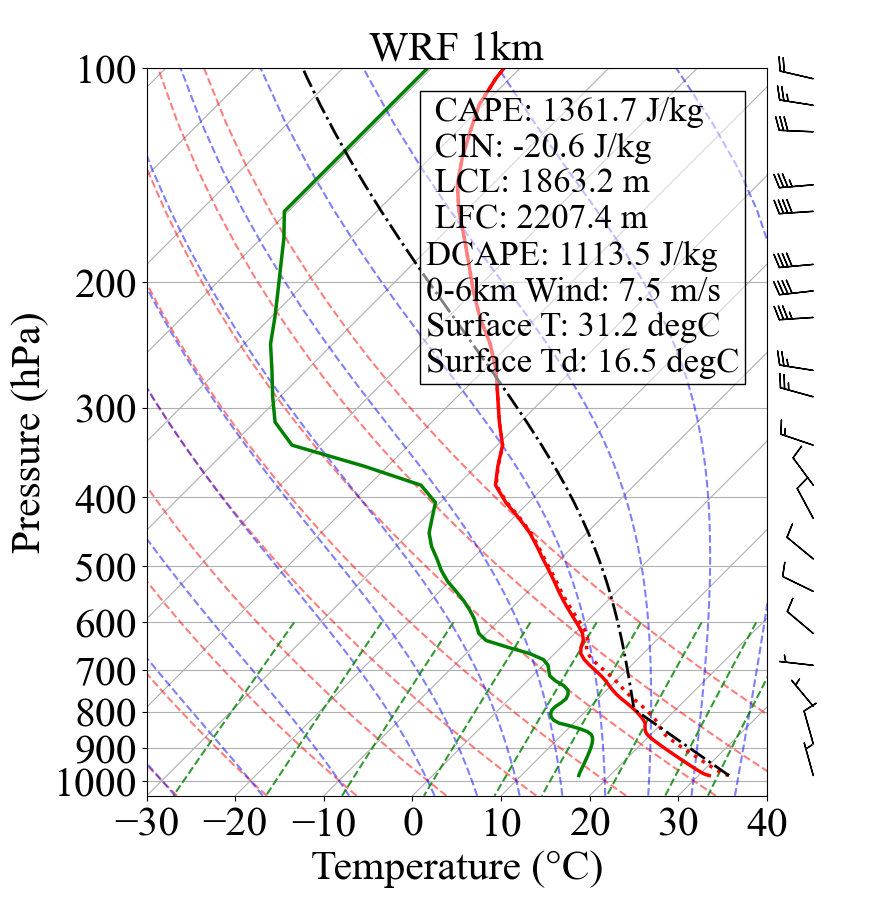

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/numpy/lib/function_base.py:1599: UserWarning: Warning: converting a masked element to nan.
  return interp_func(x, xp, fp, left, right)


In [ ]:
for case in ["CASE1", "CASE2_new"]:
    coarsen = True    
    path_all = f"{path_profiles}/ProfileAWS_{case}_{dates_radiosonde[case][0].replace(' ', 'T')[:-3]}"
    
    wrf_prof, wrf_prof_log = {}, {}
    for dom in ["d01", "d03", "d02"]:
        if coarsen:
            wrf_prof[dom]     =  pd.read_csv(f"{path_all}_logspaceFalse_{dom}_coarsen5km.csv", index_col = 0, dtype = float)
            wrf_prof_log[dom] = pd.read_csv(f"{path_all}_logspaceTrue_{dom}_coarsen5km.csv", index_col = 0, dtype = float)
        else:
            wrf_prof[dom]     =  pd.read_csv(f"{path_all}_logspaceFalse_{dom}.csv", index_col = 0, dtype = float)
            wrf_prof_log[dom] = pd.read_csv(f"{path_all}_logspaceTrue_{dom}.csv", index_col = 0, dtype = float)            
    
    plot_wrf("d01", f"WRF 5km", f"Figure_S1_{case}_d01")
    plot_wrf("d02", f"WRF 1km", f"Figure_S1_{case}_d02")
    plot_wrf("d03", f"WRF 200m", f"Figure_S1_{case}_d03")